In [1]:
!pip install augly
! pip install librosa
# Mount drive if not already mounted
import google.colab.drive as drive
import os
if not os.path.exists('/content/drive'):
    drive.mount('/content/drive')
import re
import librosa
import torch
import numpy as np
from torch.utils.data import Dataset
from PIL import Image
import sys

# Fix for augly/torchaudio compatibility in Python 3.12 / Torchaudio 2.x
import torchaudio

# Define a mock class to replace the missing sox_effects module
class SoxPatch:
    @staticmethod
    def apply_effects_tensor(tensor, sample_rate, effects, channels_first=True):
        # Most augly transforms just need the tensor returned if sox isn't handling it
        return tensor, sample_rate
# Inject the patch into sys.modules so augly can find it
if not hasattr(torchaudio, 'sox_effects'):
    mock_sox = SoxPatch()
    sys.modules['torchaudio.sox_effects'] = mock_sox
    torchaudio.sox_effects = mock_sox

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.2/42.2 kB 2.1 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.3/24.3 MB 48.2 MB/s eta 0:00:00
  Created wheel for iopath: filename=iopath-0.1.10-py3-none-any.whl size=31527 sha256=c8a6e0bec7d14cdd2b897d1de5c291e4296a5c29898bc5b776ff426c54b21155
  Stored in directory: /root/.cache/pip/wheels/7c/96/04/4f5f31ff812f684f69f40cb1634357812220aac58d4698048c
Successfully built iopath
Mounted at /content/drive


In [2]:
!git clone https://github.com/mona0101/Final-year-project-2026.git
%cd Final-year-project-2026

Cloning into 'Final-year-project-2026'...
remote: Enumerating objects: 51, done.
remote: Counting objects: 100% (51/51), done.
remote: Compressing objects: 100% (49/49), done.
remote: Total 51 (delta 25), reused 0 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (51/51), 24.62 KiB | 6.16 MiB/s, done.
Resolving deltas: 100% (25/25), done.
/content/Final-year-project-2026


Copy dataset from Google Drive to Colab’s local runtime storage, for faster training.

In [3]:
import os

# Ensure these folder names match your Drive exactly!
DRIVE_FOLDER = '/content/drive/MyDrive/Colab Notebooks'
LOCAL_TARGET = '/content/drone_dataset'

if not os.path.exists(LOCAL_TARGET):
    os.makedirs(LOCAL_TARGET)

print("Starting high-speed parallel copy... this might take a few minutes but is faster than zipping.")

!rsync -ah --progress "{DRIVE_FOLDER}/Audio" "{LOCAL_TARGET}/"
!rsync -ah --progress "{DRIVE_FOLDER}/Video" "{LOCAL_TARGET}/"
!rsync -ah --progress "{DRIVE_FOLDER}/RF_Spectrograms" "{LOCAL_TARGET}/"

print(f" All folders moved to {LOCAL_TARGET}")

Starting high-speed parallel copy... this might take a few minutes but is faster than zipping.
sending incremental file list
Audio -> /content/drive/.shortcut-targets-by-id/1_DDNngF4WEG2Z6pQh8wtcd1M0ghq7K0i/Audio
sending incremental file list
Video -> /content/drive/.shortcut-targets-by-id/1GUJY-w67Bh_uN8FzbHGR26rw_2xOdKsE/Video
sending incremental file list
RF_Spectrograms -> /content/drive/.shortcut-targets-by-id/1ImiDL8BmTC_rNPVxEYSBaq9skoFEgZG5/RF_Spectrograms
 All folders moved to /content/drone_dataset


In [4]:
from dataset_loader2 import DroneFusionDataset, get_loader
from augmentation import get_audio_transform, get_img_transform, get_rf_transform

class Args:
    dataset_dir = '/content/drone_dataset'
    batch_size = 32
    crop_size = 112
    #scale_size = 640

args = Args()
# Added augment=True to get_rf_transform to support the progression visualization
train_transform = {'audio': get_audio_transform(args, is_training=False, feature_type='mfcc'), 'video': get_img_transform(args, is_training=True, augment=False), 'rf': get_rf_transform(args, is_training=True, augment=True)}
test_transform = {'audio': get_audio_transform(args, is_training=False,feature_type='mfcc'), 'video': get_img_transform(args, is_training=False,  augment=False), 'rf': get_rf_transform(args, is_training=False,  augment=False)}
val_transform = {'audio': get_audio_transform(args, is_training=False,feature_type='mfcc'), 'video': get_img_transform(args, is_training=False,  augment=False), 'rf': get_rf_transform(args, is_training=False,  augment=False)}

audio_root = os.path.join(args.dataset_dir, 'Audio')
video_root = os.path.join(args.dataset_dir, 'Video')
rf_root = os.path.join(args.dataset_dir, 'RF_Spectrograms')


train_dataset = DroneFusionDataset(audio_root + '/Train',video_root + '/Train',rf_root + '/Train','Train',train_transform ,audio_sr=44100,modalities=['rf']) #  ONLY RF

test_dataset = DroneFusionDataset(audio_root + '/Test',video_root + '/Test',rf_root + '/Test','Test', test_transform ,modalities=['rf'])

val_dataset = DroneFusionDataset(audio_root + '/Validation',video_root + '/Validation',rf_root + '/Validation','Validation', val_transform ,modalities=['rf'])


train_loader = get_loader(train_dataset, batch_size=args.batch_size, is_train=True, num_workers=2)
test_loader  = get_loader(test_dataset,  batch_size=args.batch_size, is_train=False, num_workers=2)
val_loader = get_loader(val_dataset, batch_size=args.batch_size, is_train=False, num_workers=2)

for _, _, rf, label in train_loader:
    print("RF batch:")
    print(rf.shape, label.shape)
    break

RF batch:
torch.Size([32, 1, 3, 112, 112]) torch.Size([32])


In [6]:
print("Train samples:", len(train_dataset))
print("Val samples:", len(val_dataset))
print("Test samples:", len(test_dataset))
total_samples = len(train_dataset) + len(val_dataset) + len(test_dataset)
print("Total RF samples:", total_samples)

Train samples: 8480
Val samples: 1280
Test samples: 1320
Total RF samples: 11080


In [7]:
import torch.nn as nn

class ConvBNReLU3D(nn.Module):
    """3D convolution + BatchNorm + ReLU block"""
    def __init__(self, in_planes, out_planes, kernel_size=3, stride=1, padding=1):
        super().__init__()
        self.conv = nn.Conv3d(
            in_planes, out_planes,
            kernel_size=kernel_size,
            stride=stride,
            padding=padding,
            bias=False
        )
        self.bn = nn.BatchNorm3d(out_planes)
        self.relu = nn.ReLU(inplace=True)

    def forward(self, x):
        return self.relu(self.bn(self.conv(x)))


class Modality3DCNN(nn.Module):
    """Generic 3D CNN for video or RF frames"""
    def __init__(self, in_channels=3, num_classes=2):
        super().__init__()

        # 3D CNN blocks
        self.conv1 = ConvBNReLU3D(in_channels, 32, stride=1)
        self.conv2 = ConvBNReLU3D(32, 64, stride=2)
        self.conv3 = ConvBNReLU3D(64, 128, stride=2)
        self.conv4 = ConvBNReLU3D(128, 256, stride=2)

        # Adaptive pooling → fixed-size feature vector
        self.avg_pool = nn.AdaptiveAvgPool3d((1, 1, 1))

        # Classifier
        self.fc = nn.Sequential(
            nn.Linear(256, num_classes - 1),  # binary classification
            nn.Sigmoid()
        )

    def forward(self, x):
        """
        Args:
            x: [B, T, C, H, W]
               - T = number of frames (video or RF segment)
               - C = channels (3 for RGB, 1 for grayscale)
        """
        if x.ndim != 5:
            raise ValueError("Input tensor must be 5D: [B, T, C, H, W]")

        # Convert to [B, C, T, H, W] for nn.Conv3d
        x = x.permute(0, 2, 1, 3, 4).contiguous()

        # Forward pass
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)

        # Global average pooling
        x = self.avg_pool(x)  # [B, 256, 1, 1, 1]
        x = torch.flatten(x, 1)  # [B, 256]

        out = self.fc(x)
        return out.squeeze()

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


Initialize Model

In [9]:
model = Modality3DCNN(in_channels=3, num_classes=2)
model = model.to(device)

Loss & Optimizer

In [10]:
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

In [11]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

Training Loop

In [12]:
def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for _, _, rf, label in loader:
        rf = rf.to(device)
        label = label.float().to(device)

        optimizer.zero_grad()
        outputs = model(rf)
        loss = criterion(outputs, label)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        preds = (outputs > 0.5).float()
        correct += (preds == label).sum().item()
        total += label.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

Validation Loop

In [13]:
def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():
        for _, _, rf, label in loader:
            rf = rf.to(device)
            label = label.float().to(device)

            outputs = model(rf)
            loss = criterion(outputs, label)

            running_loss += loss.item()

            preds = (outputs > 0.5).float()
            correct += (preds == label).sum().item()
            total += label.size(0)

    epoch_loss = running_loss / len(loader)
    epoch_acc = correct / total

    return epoch_loss, epoch_acc

In [14]:
num_epochs = 10

best_val_loss = float('inf')
patience = 3
counter = 0

for epoch in range(num_epochs):

    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion, device)
    val_loss, val_acc = evaluate(model, val_loader, criterion, device)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accuracies.append(train_acc)
    val_accuracies.append(val_acc)

    print(f"Epoch [{epoch+1}/{num_epochs}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.4f}")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.4f}")
    print("-"*50)

    # EARLY STOPPING

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_model.pth")
    else:
        counter += 1

    if counter >= patience:
        print("Early stopping triggered.")
        break

Epoch [1/10]
Train Loss: 0.2895 | Train Acc: 0.8814
Val   Loss: 0.1365 | Val   Acc: 0.9477
--------------------------------------------------
Epoch [2/10]
Train Loss: 0.1892 | Train Acc: 0.9325
Val   Loss: 0.0783 | Val   Acc: 0.9781
--------------------------------------------------
Epoch [3/10]
Train Loss: 0.1712 | Train Acc: 0.9383
Val   Loss: 0.0887 | Val   Acc: 0.9711
--------------------------------------------------
Epoch [4/10]
Train Loss: 0.1517 | Train Acc: 0.9505
Val   Loss: 0.0893 | Val   Acc: 0.9742
--------------------------------------------------
Epoch [5/10]
Train Loss: 0.1244 | Train Acc: 0.9591
Val   Loss: 0.0701 | Val   Acc: 0.9789
--------------------------------------------------
Epoch [6/10]
Train Loss: 0.1284 | Train Acc: 0.9570
Val   Loss: 0.0898 | Val   Acc: 0.9633
--------------------------------------------------
Epoch [7/10]
Train Loss: 0.1247 | Train Acc: 0.9613
Val   Loss: 0.0800 | Val   Acc: 0.9727
--------------------------------------------------
Epoch 

In [15]:
test_loss, test_acc = evaluate(model, test_loader, criterion, device)

print("Test Results:")
print(f"Loss: {test_loss:.4f}")
print(f"Accuracy: {test_acc:.4f}")

Test Results:
Loss: 0.0930
Accuracy: 0.9705


In [16]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

def evaluate_metrics(model, dataloader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for _, _, rf, labels in dataloader:
            rf = rf.to(device)
            labels = labels.to(device)

            outputs = model(rf)  # [B]
            preds = (outputs > 0.5).long()  # threshold sigmoid at 0.5

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    return acc, prec, rec, f1

Plot Accuracy & Loss

In [17]:
train_acc, train_prec, train_rec, train_f1 = evaluate_metrics(model, train_loader, device)
val_acc, val_prec, val_rec, val_f1 = evaluate_metrics(model, val_loader, device)
test_acc, test_prec, test_rec, test_f1 = evaluate_metrics(model, test_loader, device)

print(f"Train: Accuracy={train_acc:.4f}, Precision={train_prec:.4f}, Recall={train_rec:.4f}, F1-score={train_f1:.4f}")
print(f"Val  : Accuracy={val_acc:.4f}, Precision={val_prec:.4f}, Recall={val_rec:.4f}, F1-score={val_f1:.4f}")
print(f"Test : Accuracy={test_acc:.4f}, Precision={test_prec:.4f}, Recall={test_rec:.4f}, F1-score={test_f1:.4f}")

Train: Accuracy=0.9700, Precision=0.9960, Recall=0.9500, F1-score=0.9725
Val  : Accuracy=0.9727, Precision=0.9948, Recall=0.9613, F1-score=0.9777
Test : Accuracy=0.9705, Precision=0.9988, Recall=0.9548, F1-score=0.9763


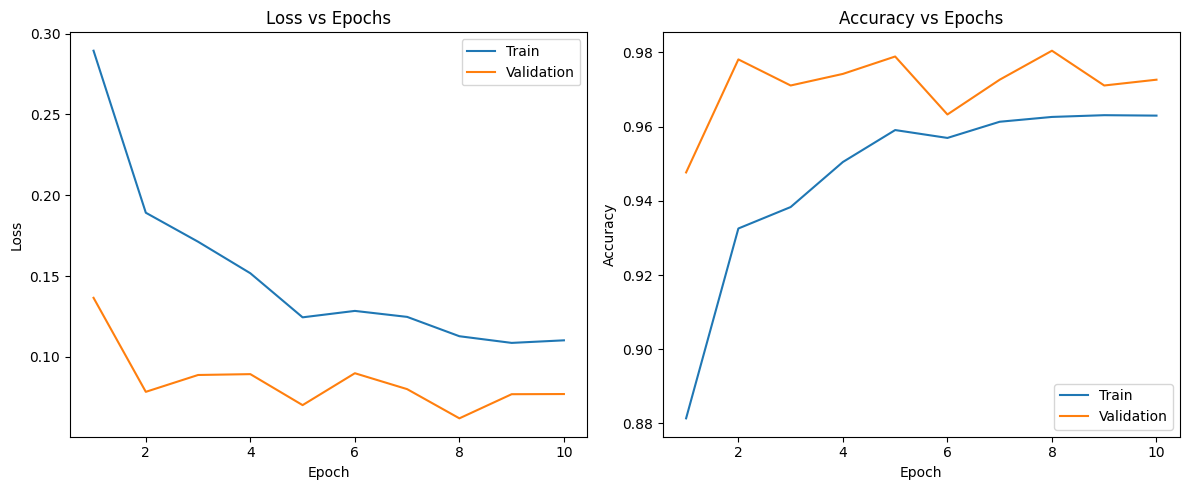

In [26]:
import matplotlib.pyplot as plt

epochs = range(1, num_epochs+1)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Loss Plot
axes[0].plot(epochs, train_losses)
axes[0].plot(epochs, val_losses)
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].set_title("Loss vs Epochs")
axes[0].legend(["Train", "Validation"])

# Accuracy Plot
axes[1].plot(epochs, train_accuracies)
axes[1].plot(epochs, val_accuracies)
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs Epochs")
axes[1].legend(["Train", "Validation"])

plt.tight_layout()
plt.show()

Full Evaluation Metrics (Train / Val / Test)

In [19]:
def evaluate_metrics(model, dataloader, device, name="Set"):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for _, _, rf, labels in dataloader:
            rf = rf.to(device)
            labels = labels.to(device)

            outputs = model(rf)
            preds = (outputs > 0.5).long()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds)
    rec = recall_score(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds)

    print(f"\n{name} Metrics:")
    print(f"Accuracy : {acc:.4f}")
    print(f"Precision: {prec:.4f}")
    print(f"Recall   : {rec:.4f}")
    print(f"F1-score : {f1:.4f}")

    print("\nPer-Class Report:")
    print(classification_report(all_labels, all_preds, target_names=["No-Drone","Drone"]))

    return all_labels, all_preds

In [20]:
train_labels, train_preds = evaluate_metrics(model, train_loader, device, "Train")
val_labels, val_preds = evaluate_metrics(model, val_loader, device, "Validation")
test_labels, test_preds = evaluate_metrics(model, test_loader, device, "Test")


Train Metrics:
Accuracy : 0.9696
Precision: 0.9962
Recall   : 0.9489
F1-score : 0.9720

Per-Class Report:
              precision    recall  f1-score   support

    No-Drone       0.94      1.00      0.97      3760
       Drone       1.00      0.95      0.97      4720

    accuracy                           0.97      8480
   macro avg       0.97      0.97      0.97      8480
weighted avg       0.97      0.97      0.97      8480


Validation Metrics:
Accuracy : 0.9727
Precision: 0.9948
Recall   : 0.9613
F1-score : 0.9777

Per-Class Report:
              precision    recall  f1-score   support

    No-Drone       0.94      0.99      0.96       480
       Drone       0.99      0.96      0.98       800

    accuracy                           0.97      1280
   macro avg       0.97      0.98      0.97      1280
weighted avg       0.97      0.97      0.97      1280


Test Metrics:
Accuracy : 0.9705
Precision: 0.9988
Recall   : 0.9548
F1-score : 0.9763

Per-Class Report:
              precisi

Compute Per-Class Metrics

In [21]:
def get_per_class_metrics(model, loader, device):
    model.eval()
    all_labels = []
    all_preds = []

    with torch.no_grad():
        for _, _, rf, labels in loader:
            rf = rf.to(device)
            labels = labels.to(device)

            outputs = model(rf)
            preds = (outputs > 0.5).long()

            all_labels.extend(labels.cpu().numpy())
            all_preds.extend(preds.cpu().numpy())

    all_labels = np.array(all_labels)
    all_preds = np.array(all_preds)

    precision, recall, f1, _ = precision_recall_fscore_support(
        all_labels, all_preds, average=None
    )

    cm = confusion_matrix(all_labels, all_preds)

    # Per-class accuracy = TP / total actual samples of that class
    per_class_accuracy = cm.diagonal() / cm.sum(axis=1)

    return precision, recall, f1, per_class_accuracy

Bar Plot Function

In [22]:
def plot_per_class_bar(precision, recall, f1, accuracy, title):
    class_names = ["No-Drone", "Drone"]
    x = np.arange(len(class_names))
    width = 0.2

    # Paired colors
    paired_colors = ['#1f78b4', '#a6cee3', '#b2df8a', '#33a02c']

    plt.figure()

    plt.bar(x - 1.5*width, precision, width,
            label="Precision", color=paired_colors[0])

    plt.bar(x - 0.5*width, recall, width,
            label="Recall", color=paired_colors[1])

    plt.bar(x + 0.5*width, f1, width,
            label="F1-score", color=paired_colors[2])

    plt.bar(x + 1.5*width, accuracy, width,
            label="Accuracy", color=paired_colors[3])

    plt.xticks(x, class_names)
    plt.ylim(0, 1)
    plt.ylabel("Score")
    plt.title(title)
    plt.legend()
    plt.show()

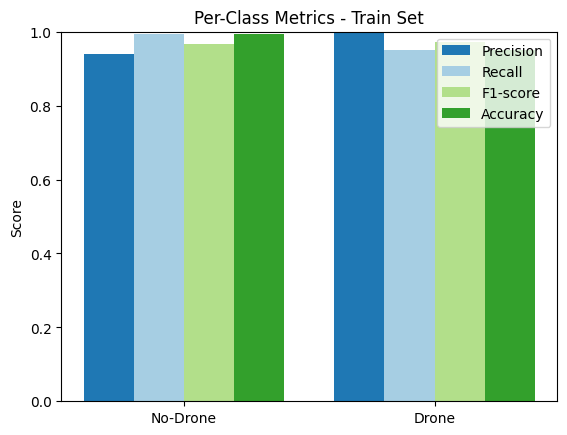

In [27]:
from sklearn.metrics import precision_recall_fscore_support, confusion_matrix

# Train
train_prec, train_rec, train_f1, train_acc_pc = get_per_class_metrics(model, train_loader, device)
plot_per_class_bar(train_prec, train_rec, train_f1, train_acc_pc,
                   "Per-Class Metrics - Train Set")

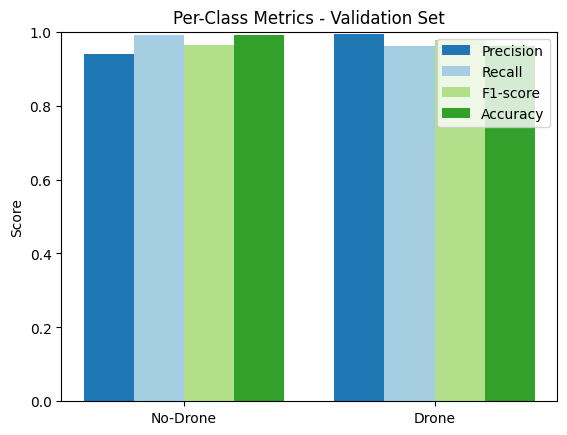

In [28]:
# Validation
val_prec, val_rec, val_f1, val_acc_pc = get_per_class_metrics(model, val_loader, device)
plot_per_class_bar(val_prec, val_rec, val_f1, val_acc_pc,
                   "Per-Class Metrics - Validation Set")

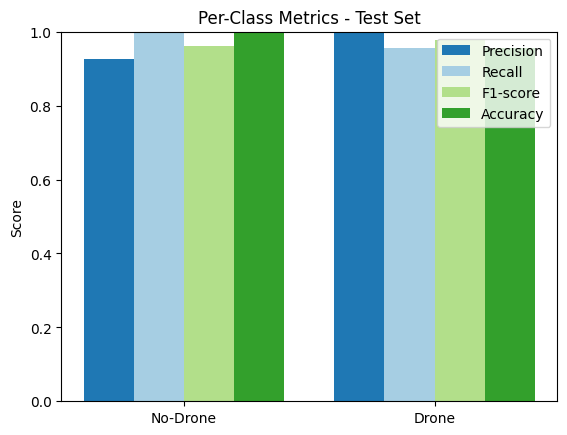

In [29]:
# Test
test_prec, test_rec, test_f1, test_acc_pc = get_per_class_metrics(model, test_loader, device)
plot_per_class_bar(test_prec, test_rec, test_f1, test_acc_pc,
                   "Per-Class Metrics - Test Set")

Visualize Per Class (Confusion Matrix)

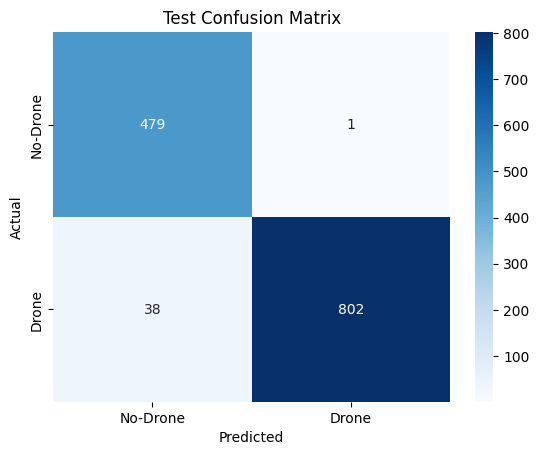

In [30]:
import seaborn as sns

def plot_confusion(labels, preds, title):
    cm = confusion_matrix(labels, preds)
    plt.figure()
    sns.heatmap(cm, annot=True, fmt='d',
                cmap="Blues",
                xticklabels=["No-Drone","Drone"],
                yticklabels=["No-Drone","Drone"])

    plt.title(title)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

plot_confusion(test_labels, test_preds, "Test Confusion Matrix")

Detection Time

In [25]:
import time

def measure_detection_time(model, loader, device):
    model.eval()
    total_time = 0
    total_samples = 0

    with torch.no_grad():
        for _, _, rf, _ in loader:
            rf = rf.to(device)

            if device.type == "cuda":
                torch.cuda.synchronize()

            start = time.time()

            outputs = model(rf)

            if device.type == "cuda":
                torch.cuda.synchronize()

            end = time.time()

            total_time += (end - start)
            total_samples += rf.size(0)

    avg_time = total_time / total_samples
    fps = 1 / avg_time

    print("\nDetection Performance:")
    print(f"Average Time per Sample: {avg_time:.6f} seconds")
    print(f"FPS (Frames per Second): {fps:.2f}")

measure_detection_time(model, test_loader, device)


Detection Performance:
Average Time per Sample: 0.000590 seconds
FPS (Frames per Second): 1694.54
